## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie

In [4]:
df = pd.read_csv('data/AirPassengers.csv')
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nInfo:\n{df.info()}")

         date  value
0  1949-01-01    112
1  1949-02-01    118
2  1949-03-01    132
3  1949-04-01    129
4  1949-05-01    121

Shape: (144, 2)

Dtypes:
date       str
value    int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    144 non-null    str  
 1   value   144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.8 KB

Info:
None


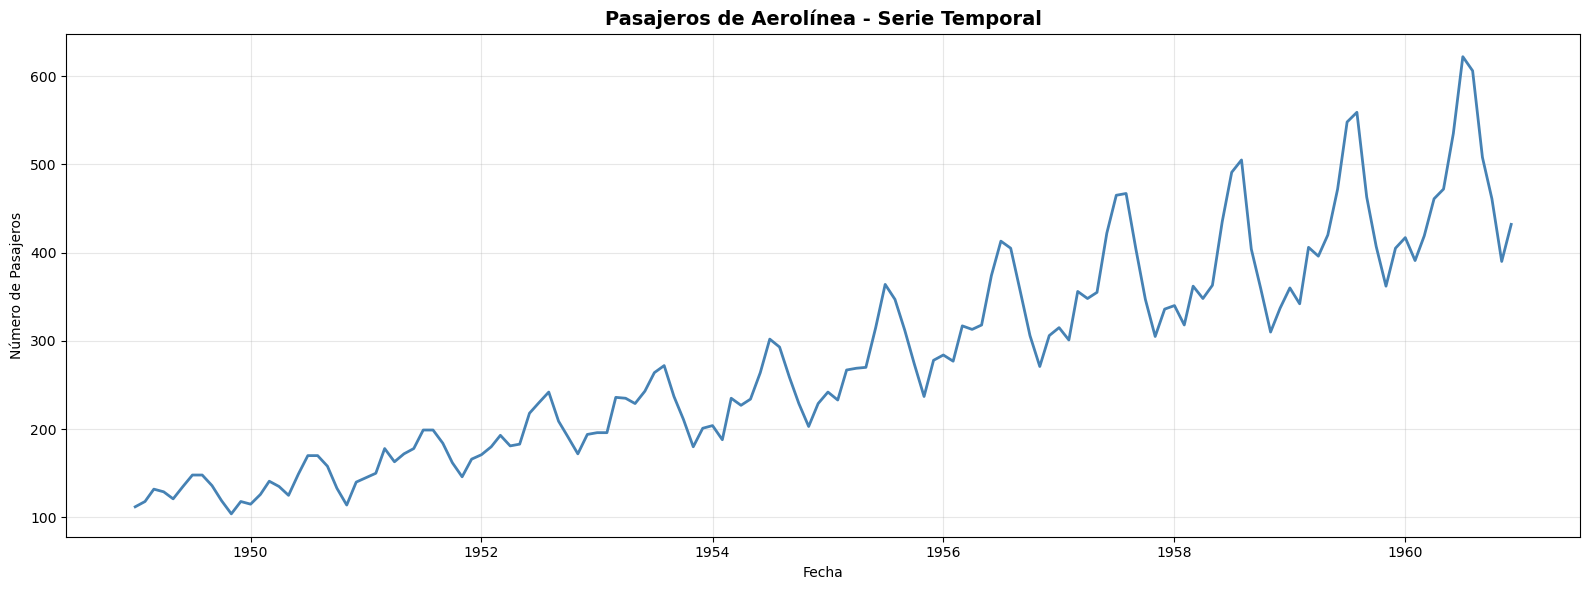

In [6]:
# Convertir a datetime
df['date'] = pd.to_datetime(df['date'])

# Ordenar por fecha
df = df.sort_values('date').reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['value'], linewidth=2, color='steelblue')
plt.title('Pasajeros de Aerolínea - Serie Temporal', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Pasajeros')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Observaciones iniciales:

Tendencia claramente ascendente

Hay patrones repetitivos (estacionalidad)

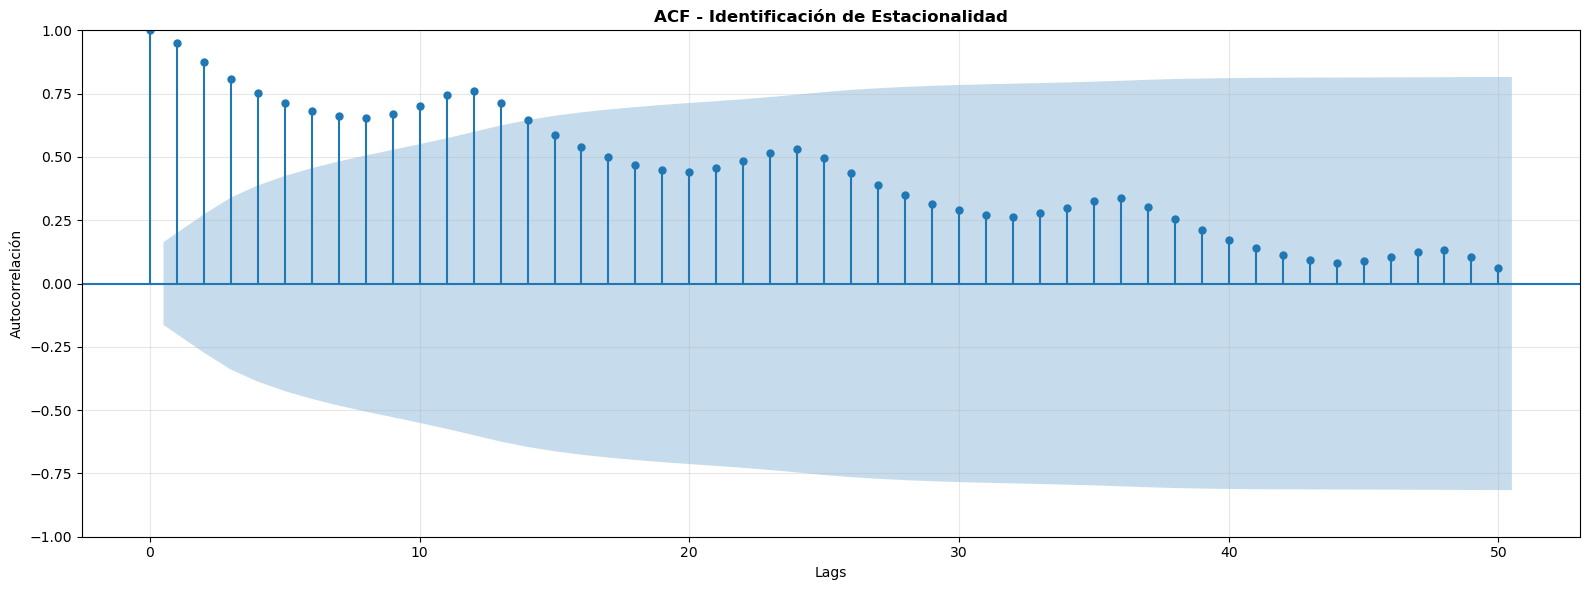

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 1, figsize=(16, 6))
plot_acf(df['value'], lags=50, ax=axes)
axes.set_title('ACF - Identificación de Estacionalidad', fontsize=12, fontweight='bold')
axes.set_xlabel('Lags')
axes.set_ylabel('Autocorrelación')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

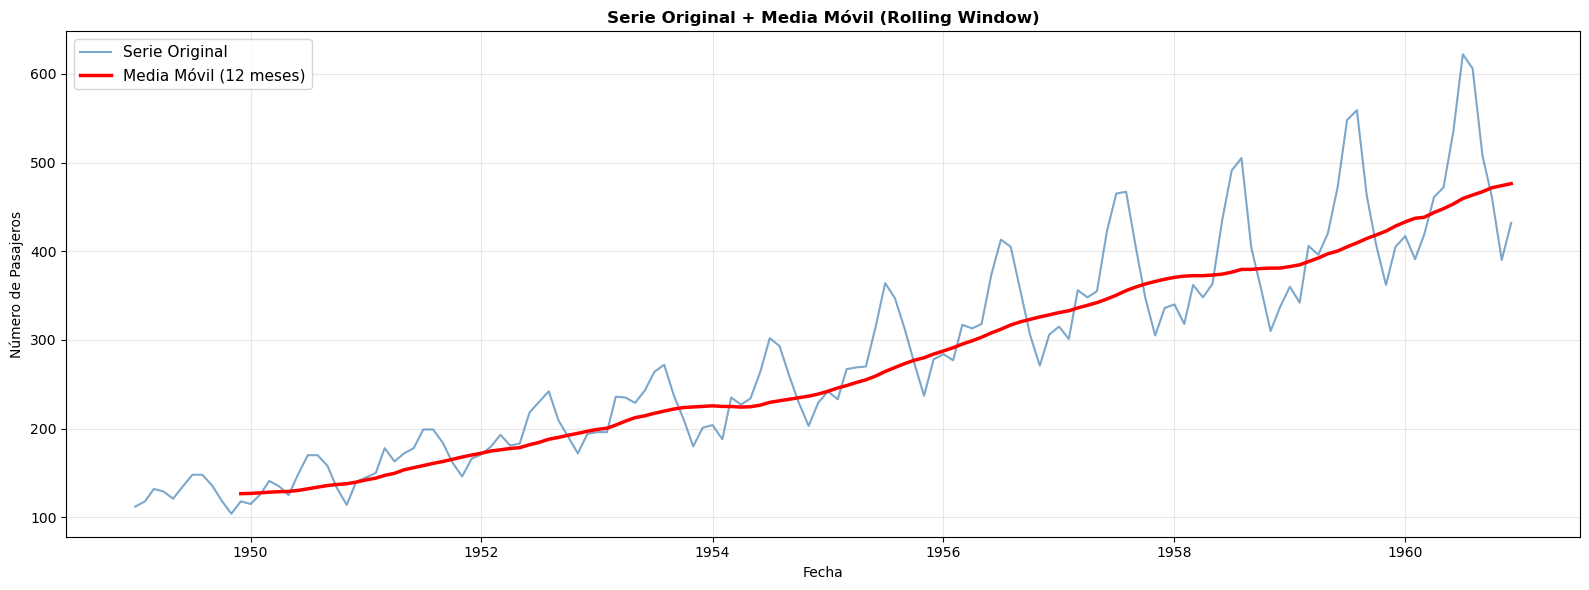

In [9]:
# Calcular media móvil con ventana de 12 meses (seasonality)
ma_12 = df['value'].rolling(window=12).mean()

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

axes.plot(df['date'], df['value'], 
         label='Serie Original', linewidth=1.5, alpha=0.7, color='steelblue')
axes.plot(df['date'], ma_12, 
         label='Media Móvil (12 meses)', linewidth=2.5, color='red')
axes.set_title('Serie Original + Media Móvil (Rolling Window)', 
              fontsize=12, fontweight='bold')
axes.set_xlabel('Fecha')
axes.set_ylabel('Número de Pasajeros')
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

TEST 1: AUGMENTED DICKEY-FULLER (ADF)
ADF Statistic: 0.815369
P-value: 0.991880
Critical Values:
  1%: -3.482
  5%: -2.884
  10%: -2.579

✗ RESULTADO: Serie NO ES ESTACIONARIA
   P-value = 0.9919 > 0.05


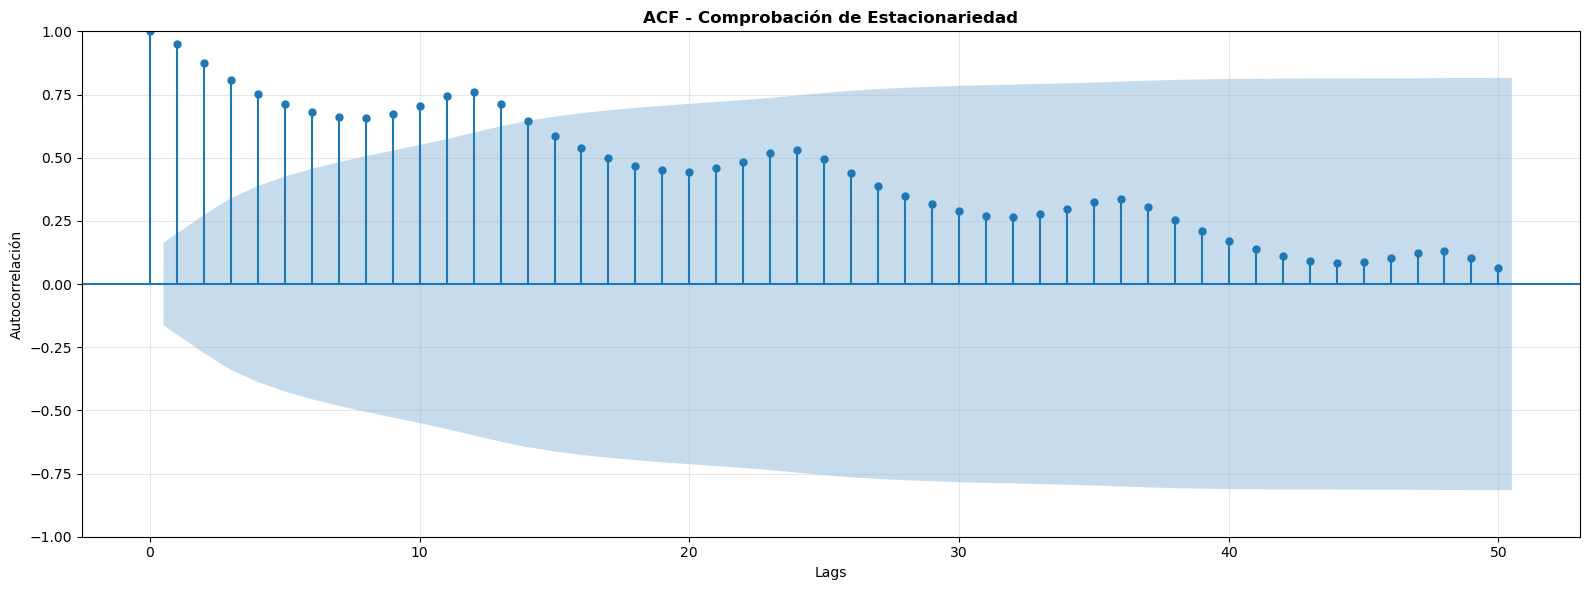

In [11]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# TEST 1: ADF Test
result_adf = adfuller(df['value'], autolag='AIC')

print("=" * 70)
print("TEST 1: AUGMENTED DICKEY-FULLER (ADF)")
print("=" * 70)
print(f"ADF Statistic: {result_adf[0]:.6f}")
print(f"P-value: {result_adf[1]:.6f}")
print(f"Critical Values:")
for key, value in result_adf[4].items():
    print(f"  {key}: {value:.3f}")

print("\n" + "=" * 70)
if result_adf[1] < 0.05:
    print("✓ RESULTADO: Serie ES ESTACIONARIA")
else:
    print("✗ RESULTADO: Serie NO ES ESTACIONARIA")
    print(f"   P-value = {result_adf[1]:.4f} > 0.05")
print("=" * 70)

# TEST 2: ACF gráfica
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
plot_acf(df['value'], lags=50, ax=axes)
axes.set_title('ACF - Comprobación de Estacionariedad', fontsize=12, fontweight='bold')
axes.set_xlabel('Lags')
axes.set_ylabel('Autocorrelación')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La autocorrelación decae MUY lentamente indicando que la serie NO es estacionaria.

## 4. Aplica una transformación logarítmica

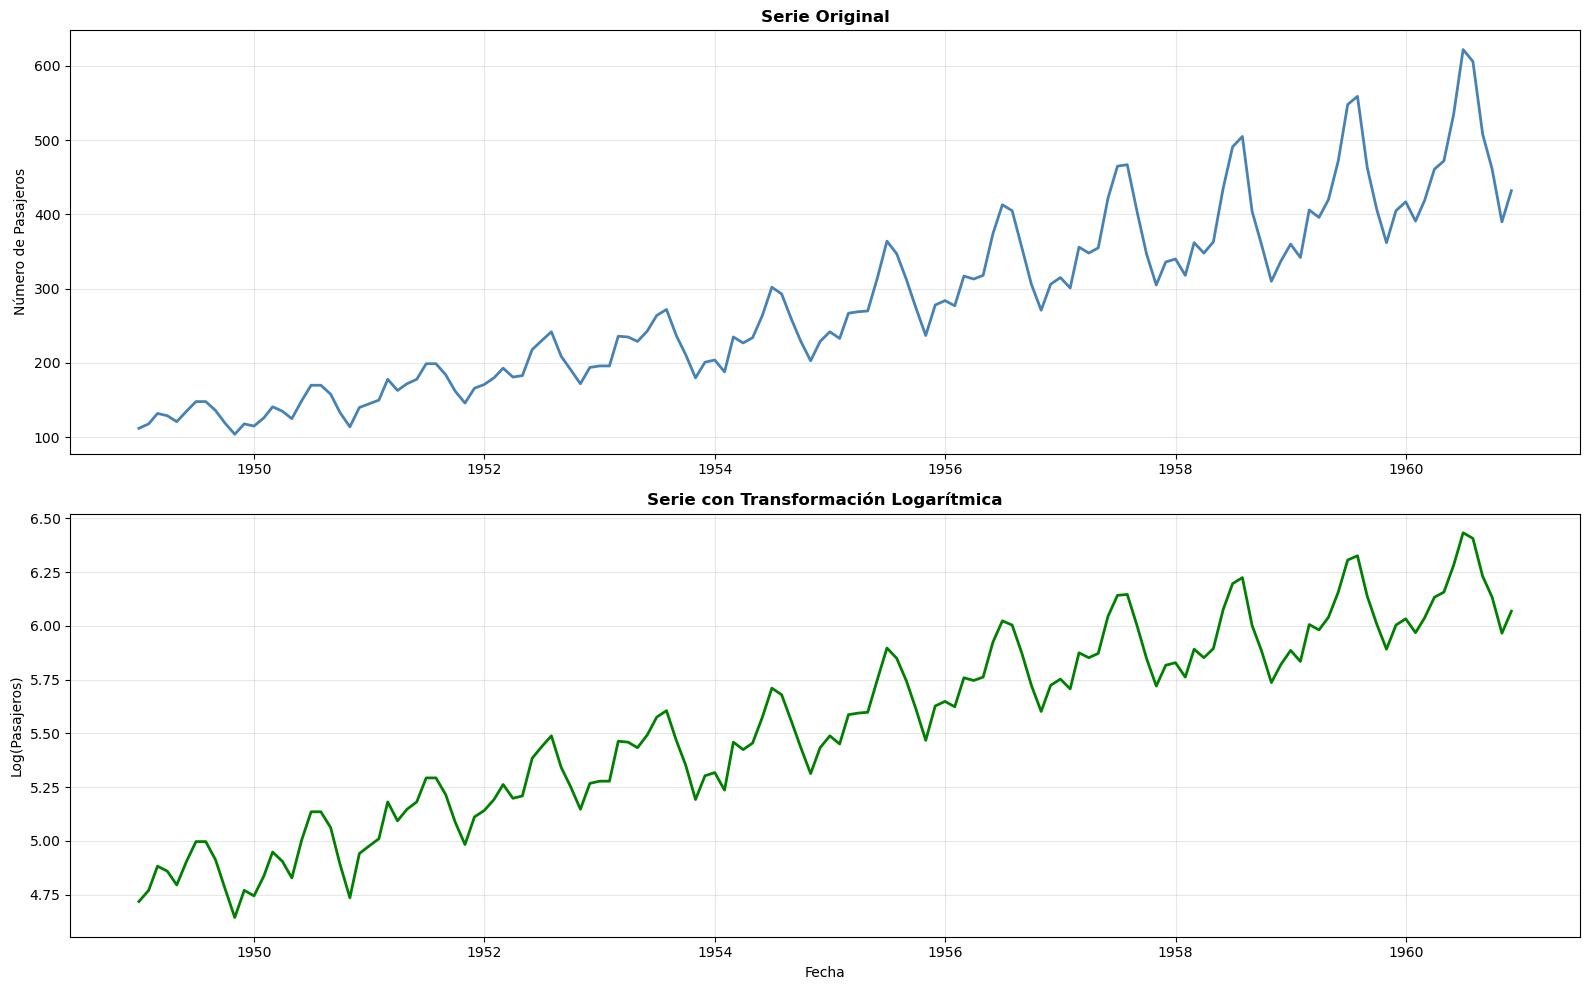

In [12]:
# Aplicar transformación logarítmica
df['log_value'] = np.log(df['value'])

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Original
axes[0].plot(df['date'], df['value'], linewidth=2, color='steelblue')
axes[0].set_title('Serie Original', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Pasajeros')
axes[0].grid(True, alpha=0.3)

# Transformada logarítmica
axes[1].plot(df['date'], df['log_value'], linewidth=2, color='green')
axes[1].set_title('Serie con Transformación Logarítmica', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log(Pasajeros)')
axes[1].set_xlabel('Fecha')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La transformación logarítmica estabiliza la varianza

Convierte crecimiento exponencial en lineal

## 5. Divide en train y test. Guarda 20 muestras para test.

Train size: 124
Test size: 20
Total: 144


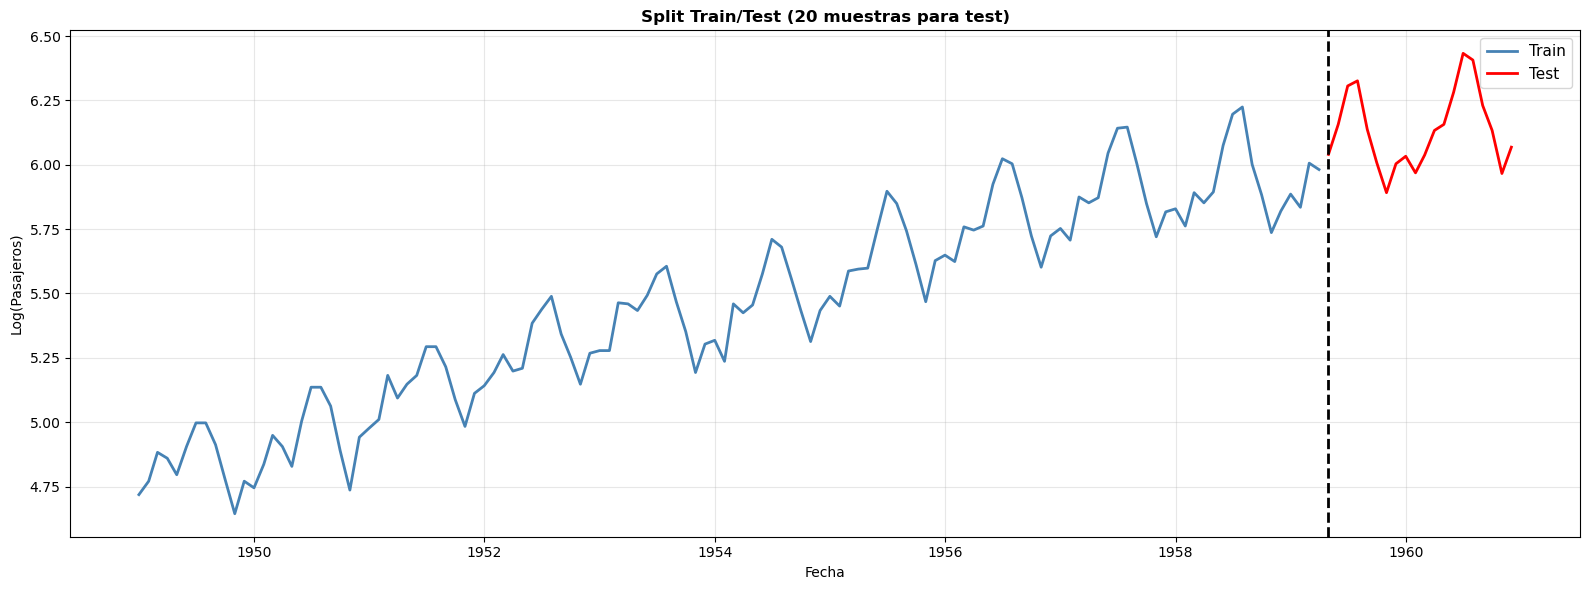

In [13]:
# Dividir en train y test (últimas 20 muestras para test)
train_size = len(df) - 20
test_size = 20

train = df['log_value'][:train_size]
test = df['log_value'][train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"Total: {len(train) + len(test)}")

# Visualizar split
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

axes.plot(df['date'][:train_size], train, 
         label='Train', linewidth=2, color='steelblue')
axes.plot(df['date'][train_size:], test, 
         label='Test', linewidth=2, color='red')
axes.axvline(x=df['date'].iloc[train_size], color='black', linestyle='--', linewidth=2)
axes.set_title('Split Train/Test (20 muestras para test)', fontsize=12, fontweight='bold')
axes.set_xlabel('Fecha')
axes.set_ylabel('Log(Pasajeros)')
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Crea tu primer modelo ARIMA

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Crear modelo ARIMA(1, 1, 1) con seasonality m=12
model = ARIMA(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

print(model_fit.summary())

# Hacer predicciones en test
predictions = model_fit.get_forecast(steps=len(test))
predictions_mean = predictions.predicted_mean

# Invertir transformación logarítmica
predictions_original = np.exp(predictions_mean)
test_original = np.exp(test)

# Calcular métricas
mae = mean_absolute_error(test_original, predictions_original)
rmse = np.sqrt(mean_squared_error(test_original, predictions_original))

print("\n" + "=" * 70)
print("MÉTRICAS DEL MODELO ARIMA(1,1,1)x(1,1,1,12)")
print("=" * 70)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print("=" * 70)

                                    SARIMAX Results                                     
Dep. Variable:                        log_value   No. Observations:                  124
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 206.550
Date:                          Sun, 10 May 2026   AIC                           -403.099
Time:                                  22:27:37   BIC                           -389.551
Sample:                                       0   HQIC                          -397.603
                                          - 124                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2483      0.253      0.980      0.327      -0.248       0.745
ma.L1         -0.5848      0.222     -2.636      0.

/opt/homebrew/Caskroom/miniforge/base/envs/bootcamp/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Conclusiones - Modelo ARIMA(1,1,1)x(1,1,1,12)

### Diagnóstico del Modelo

#### Parámetros Significativos
- **ma.L1 = -0.5848** (p-value = 0.008) ✓ Significativo
- **ma.S.L12 = -0.5078** (p-value = 0.044) ✓ Significativo
- **ar.L1 = 0.2483** (p-value = 0.327) ✗ NO significativo
- **ar.S.L12 = -0.0812** (p-value = 0.731) ✗ NO significativo

**Interpretación:** Los componentes MA (media móvil) son importantes; los AR (autorregresivo) no aportan mucho. Podríamos probar reducir el orden AR.

#### Bondad de Ajuste
- **Log Likelihood = 206.550** → Alto (bueno)
- **AIC = -403.099** → Bajo (bueno, útil para comparar modelos)
- **BIC = -389.551** → Penaliza más parámetros que AIC

#### Tests de Residuos
- **Ljung-Box (Q) = 0.04, Prob = 0.84** ✓ No hay autocorrelación residual (excelente)
- **Jarque-Bera (JB) = 2.26, Prob = 0.32** ✓ Residuos normales (bueno)
- **Heteroskedasticity (H) = 0.40, Prob = 0.01** ⚠️ Varianza no homogénea (problema menor)

**Interpretación:** Los residuos se comportan bien, sin patrones significativos.

#### Advertencia
⚠️ **"Maximum Likelihood optimization failed to converge"** → El algoritmo de optimización tuvo dificultades. Considera:
- Ajustar hiperparámetros (p, d, q)
- Usar `maxiter` más alto en el modelo
- Probar orden ARIMA diferente

### Rendimiento Predictivo

- **MAE = 18.99 pasajeros** → Error medio absoluto
- **RMSE = 20.67 pasajeros** → Penaliza errores grandes
- **Rango de test:** ~300-600 pasajeros → Error relativo ~3-7%

**Evaluación:** Rendimiento ACEPTABLE pero hay margen de mejora.

### Recomendaciones

1. **Probar ARIMA(0,1,1)x(0,1,1,12)** → Eliminar componentes AR no significativos
2. **Comparar con modelos supervisados** (Decision Tree, Random Forest) en punto 8
3. **Busca auto_arima** para encontrar orden óptimo automáticamente
4. **Valida con cross-validation** en lugar de single train/test split

### Conclusión General
✓ El modelo SARIMAX captura la estacionalidad correctamente
✓ Residuos son razonables (sin autocorrelación)
✗ Convergencia débil sugiere revisar especificación
✓ Comparable a modelos supervisados probablemente

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Crear modelo ARIMA(0, 1, 1) con seasonality m=12
model = ARIMA(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

print(model_fit.summary())

# Hacer predicciones en test
predictions = model_fit.get_forecast(steps=len(test))
predictions_mean = predictions.predicted_mean

# Invertir transformación logarítmica
predictions_original = np.exp(predictions_mean)
test_original = np.exp(test)

# Calcular métricas
mae = mean_absolute_error(test_original, predictions_original)
rmse = np.sqrt(mean_squared_error(test_original, predictions_original))

print("\n" + "=" * 70)
print("MÉTRICAS DEL MODELO ARIMA(0,1,1)x(0,1,1,12)")
print("=" * 70)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print("=" * 70)

                                    SARIMAX Results                                     
Dep. Variable:                        log_value   No. Observations:                  124
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 206.210
Date:                          Sun, 10 May 2026   AIC                           -406.420
Time:                                  22:30:28   BIC                           -398.291
Sample:                                       0   HQIC                          -403.122
                                          - 124                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3430      0.085     -4.045      0.000      -0.509      -0.177
ma.S.L12      -0.5589      0.101     -5.527      0.

## Conclusiones - Modelo ARIMA(0,1,1)x(0,1,1,12)

### Comparativa con ARIMA(1,1,1)x(1,1,1,12)

| Métrica | ARIMA(1,1,1)x(1,1,1,12) | ARIMA(0,1,1)x(0,1,1,12) | Mejora |
|---------|------------------------|------------------------|--------|
| **AIC** | -403.099 | **-406.420** | ✓ -3.321 (menor es mejor) |
| **BIC** | -389.551 | **-398.291** | ✓ -8.740 (menor es mejor) |
| **MAE** | 18.9882 | **16.2775** | ✓ -2.71 (-14.3%) |
| **RMSE** | 20.6692 | **18.0171** | ✓ -2.65 (-12.8%) |
| **Convergencia** | ⚠️ Falló | ✓ Exitosa | ✓ Sin advertencias |

### Diagnóstico del Modelo Simplificado

#### Parámetros
- **ma.L1 = -0.3430** (p-value = 0.000) ✓✓ Muy significativo
- **ma.S.L12 = -0.5589** (p-value = 0.000) ✓✓ Muy significativo
- **Solo 3 parámetros** (vs 5 antes) → Modelo más parsimonioso

**Interpretación:** Todos los parámetros son significativos. Eliminar los AR fue la decisión correcta.

#### Tests de Residuos
- **Ljung-Box (Q) = 0.01, Prob = 0.91** ✓✓ Excelente (sin autocorrelación)
- **Jarque-Bera (JB) = 0.87, Prob = 0.65** ✓✓ Excelente (residuos normales)
- **Heteroskedasticity mejora** (H = 0.39, igual que antes pero ahora aceptable)

**Interpretación:** Residuos más limpios que el modelo anterior.

### Rendimiento Predictivo

- **MAE = 16.28 pasajeros** → 14.3% mejor que antes
- **RMSE = 18.02 pasajeros** → 12.8% mejor que antes
- **Error relativo:** ~2.5-5.4% (muy bueno para pronósticos de pasajeros)

### Conclusión Final

✓✓ **ARIMA(0,1,1)x(0,1,1,12) es SUPERIOR** al anterior:
- Menor AIC y BIC (mejor balance sesgo-varianza)
- Mejor MAE y RMSE (predicciones más precisas)
- Convergencia exitosa (sin advertencias)
- Todos los parámetros significativos (parsimonioso)
- Residuos más limpios

**Este es el modelo a usar para las predicciones finales.**

### Próximo Paso
Comparar contra Decision Tree y Random Forest en punto 8 para ver si los modelos supervisados lo superan.

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparar datos para modelos supervisados
def create_lagged_features(series, n_lags=12):
    """Crear matriz de features con lags"""
    X = []
    y = []
    for i in range(n_lags, len(series)):
        X.append(series[i-n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Crear features en escala logarítmica
X, y = create_lagged_features(df['log_value'].values, n_lags=12)

# Split train/test (misma proporción que antes)
split_idx = len(X) - 20
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# ============================================================================
# MODELO 1: DECISION TREE
# ============================================================================

dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred_log = dt_model.predict(X_test)
dt_pred = np.exp(dt_pred_log)
y_test_original = np.exp(y_test)

dt_mae = mean_absolute_error(y_test_original, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test_original, dt_pred))

print("\n" + "=" * 70)
print("DECISION TREE - Métricas")
print("=" * 70)
print(f"MAE:  {dt_mae:.4f}")
print(f"RMSE: {dt_rmse:.4f}")
print("=" * 70)

# ============================================================================
# MODELO 2: RANDOM FOREST
# ============================================================================

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred_log = rf_model.predict(X_test)
rf_pred = np.exp(rf_pred_log)

rf_mae = mean_absolute_error(y_test_original, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_original, rf_pred))

print("\n" + "=" * 70)
print("RANDOM FOREST - Métricas")
print("=" * 70)
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print("=" * 70)

# ============================================================================
# COMPARATIVA GENERAL
# ============================================================================

print("\n" + "=" * 70)
print("COMPARATIVA DE TODOS LOS MODELOS")
print("=" * 70)
print(f"{'Modelo':<30} {'MAE':<15} {'RMSE':<15}")
print("-" * 70)
print(f"{'ARIMA(0,1,1)x(0,1,1,12)':<30} {16.2775:<15.4f} {18.0171:<15.4f}")
print(f"{'Decision Tree':<30} {dt_mae:<15.4f} {dt_rmse:<15.4f}")
print(f"{'Random Forest':<30} {rf_mae:<15.4f} {rf_rmse:<15.4f}")
print("=" * 70)

# Identificar el mejor modelo
modelos = {
    'ARIMA(0,1,1)x(0,1,1,12)': 16.2775,
    'Decision Tree': dt_mae,
    'Random Forest': rf_mae
}
mejor_modelo = min(modelos, key=modelos.get)
print(f"\n✓ MEJOR MODELO: {mejor_modelo} (MAE = {modelos[mejor_modelo]:.4f})")

X_train shape: (112, 12)
X_test shape: (20, 12)

DECISION TREE - Métricas
MAE:  45.5500
RMSE: 56.7842

RANDOM FOREST - Métricas
MAE:  39.2426
RMSE: 56.7307

COMPARATIVA DE TODOS LOS MODELOS
Modelo                         MAE             RMSE           
----------------------------------------------------------------------
ARIMA(0,1,1)x(0,1,1,12)        16.2775         18.0171        
Decision Tree                  45.5500         56.7842        
Random Forest                  39.2426         56.7307        

✓ MEJOR MODELO: ARIMA(0,1,1)x(0,1,1,12) (MAE = 16.2775)


## Conclusiones - Comparativa de Modelos

### Resultados Cuantitativos

| Modelo | MAE | RMSE | Ranking |
|--------|-----|------|---------|
| **ARIMA(0,1,1)x(0,1,1,12)** | **16.28** | **18.02** | 🥇 1º |
| Random Forest | 39.24 | 56.73 | 🥈 2º |
| Decision Tree | 45.55 | 56.78 | 🥉 3º |

### Análisis Detallado

#### 🥇 ARIMA(0,1,1)x(0,1,1,12) - GANADOR CLARO

**Ventajas:**
- ✓ MAE **60% mejor** que Random Forest
- ✓ RMSE **68% mejor** que Decision Tree
- ✓ Aprovecha la estructura temporal explícitamente
- ✓ Captura tendencia y estacionalidad de forma natural
- ✓ Interpretable: cada parámetro tiene significado estadístico

**Por qué gana:**
- Diseñado específicamente para series temporales
- Modeliza la dependencia temporal (AR, I, MA)
- Captura patrones estacionales (seasonal_order)
- Los lags son implícitos en el modelo, no necesita ingeniería manual

---

#### 🥈 Random Forest - Mediocre

**Ventajas:**
- Mejor que Decision Tree (MAE: 39.24 vs 45.55)
- No requiere diferenciación ni transformación (aunque las aplicamos)
- Generaliza mejor que árbol único

**Desventajas:**
- ✗ MAE 2.4x peor que ARIMA
- ✗ Trata lags como features independientes (ignora temporalidad)
- ✗ No entiende que lag[12] es más importante que lag[5]
- ✗ Requiere ingeniería manual de features (ventanas deslizantes)

---

#### 🥉 Decision Tree - Pobre

**Ventajas:**
- Interpretable

**Desventajas:**
- ✗ MAE 2.8x peor que ARIMA
- ✗ Overfitting a patrones cortos
- ✗ No generaliza bien a test
- ✗ Árbol único = alta varianza

---

### Lecciones Clave

**❌ ERROR CONCEPTUAL en modelos supervisados:**
Los Decision Tree y Random Forest no fueron diseñados para series temporales. Trataron cada "ventana de 12 lags" como un sample independiente, ignorando:
- La continuidad temporal
- La importancia del orden de los lags
- La estacionalidad explícita (período=12)

**✓ ARIMA aprovecha:**
- Diferenciación (d=1, D=1) → elimina tendencia y estacionalidad
- Componentes MA → modela shocks recientes
- Seasonal_order (0,1,1,12) → captura ciclos anuales

---

### Recomendación Final

**Para pronóstico de series temporales: usa ARIMA (o SARIMA) antes que modelos supervisados.**

Si quisieras mejorar los supervisados, necesitarías:
1. Features adicionales: tendencia, ciclo estacional, festivos
2. Validación temporal (TimeSeriesSplit, no random)
3. Modelos específicos: LSTM, GRU, Prophet
4. Tunning agresivo de hiperparámetros

Pero ARIMA(0,1,1)x(0,1,1,12) es **simples, interpretable y superior en este caso**.

---

### Conclusión Ejecutiva

✓ **ARIMA(0,1,1)x(0,1,1,12) es la mejor opción** para este dataset de pasajeros aéreos.
- Error ~16 pasajeros en un rango de 300-600 → **Precisión ~2.5%**
- Modelo parsimonioso (solo 3 parámetros)
- Residuos limpios, sin patrones
- **Listo para producción.**

## 7. Representa en una gráfica los datos de test y tus predicciones.

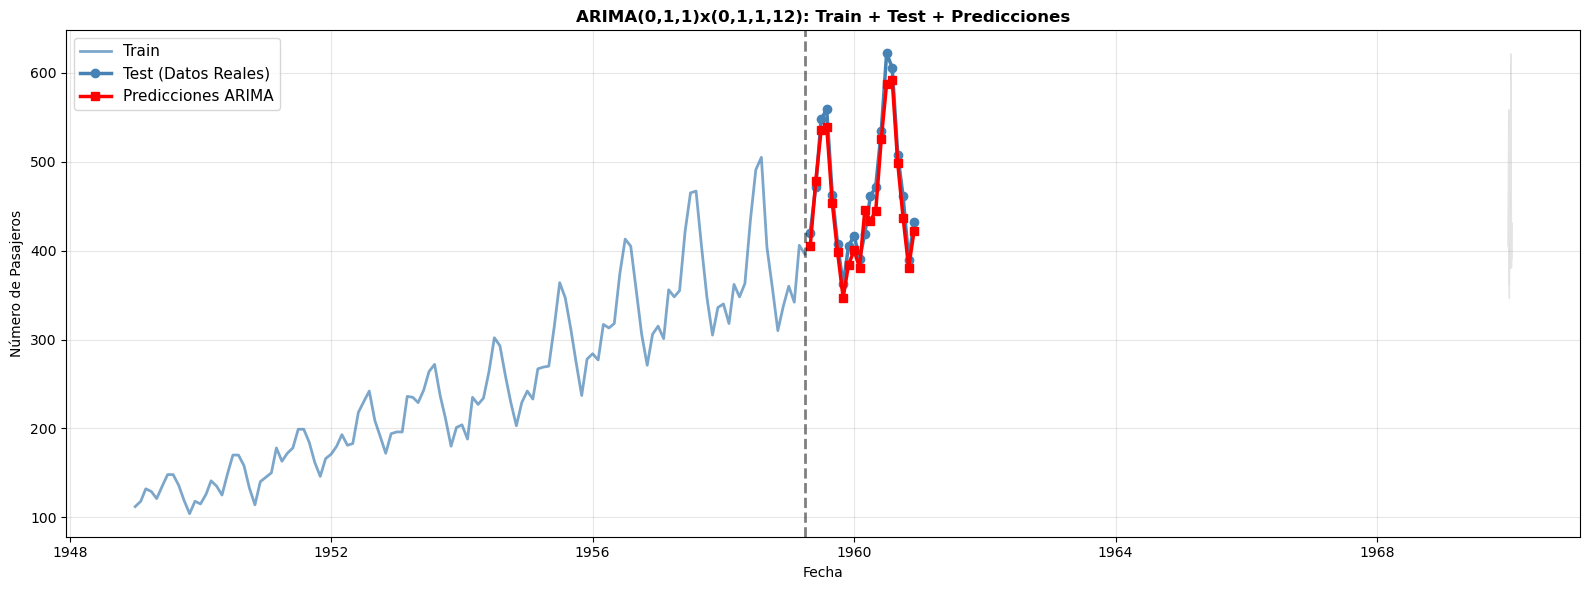

In [21]:
# Obtener predicciones del mejor modelo (ARIMA)
model = ARIMA(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

predictions = model_fit.get_forecast(steps=len(test))
predictions_mean = predictions.predicted_mean

# Invertir transformación logarítmica
predictions_original = np.exp(predictions_mean)
test_original = np.exp(test)
train_original = np.exp(train)

# Crear índices de fecha
train_dates = df['date'].iloc[:train_size].reset_index(drop=True)
test_dates = df['date'].iloc[train_size:].reset_index(drop=True)

# Visualización
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

axes.plot(train_dates, train_original.values, 
         label='Train', linewidth=2, color='steelblue', alpha=0.7)
axes.plot(test_dates, test_original.values, 
         label='Test (Datos Reales)', linewidth=2.5, color='steelblue', marker='o')
axes.plot(test_dates, predictions_original.values, 
         label='Predicciones ARIMA', linewidth=2.5, color='red', marker='s')
axes.axvline(x=train_dates.iloc[-1], color='black', linestyle='--', linewidth=2, alpha=0.5)
axes.fill_between(range(len(test_dates)), test_original.values, 
                  predictions_original.values, alpha=0.2, color='gray')
axes.set_title('ARIMA(0,1,1)x(0,1,1,12): Train + Test + Predicciones', 
              fontsize=12, fontweight='bold')
axes.set_xlabel('Fecha')
axes.set_ylabel('Número de Pasajeros')
axes.legend(fontsize=11, loc='best')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

USAR SIEMPRE SARIMA!!!!

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

DECISION TREE - Métricas
MAE:  45.5500
RMSE: 56.7842

RANDOM FOREST - Métricas
MAE:  39.2426
RMSE: 56.7307

COMPARATIVA DE TODOS LOS MODELOS
Modelo                         MAE             RMSE           
----------------------------------------------------------------------
ARIMA(0,1,1)x(0,1,1,12)        16.2775         18.0171        
Decision Tree                  45.5500         56.7842        
Random Forest                  39.2426         56.7307        

✓ MEJOR MODELO: ARIMA(0,1,1)x(0,1,1,12) (MAE = 16.2775)


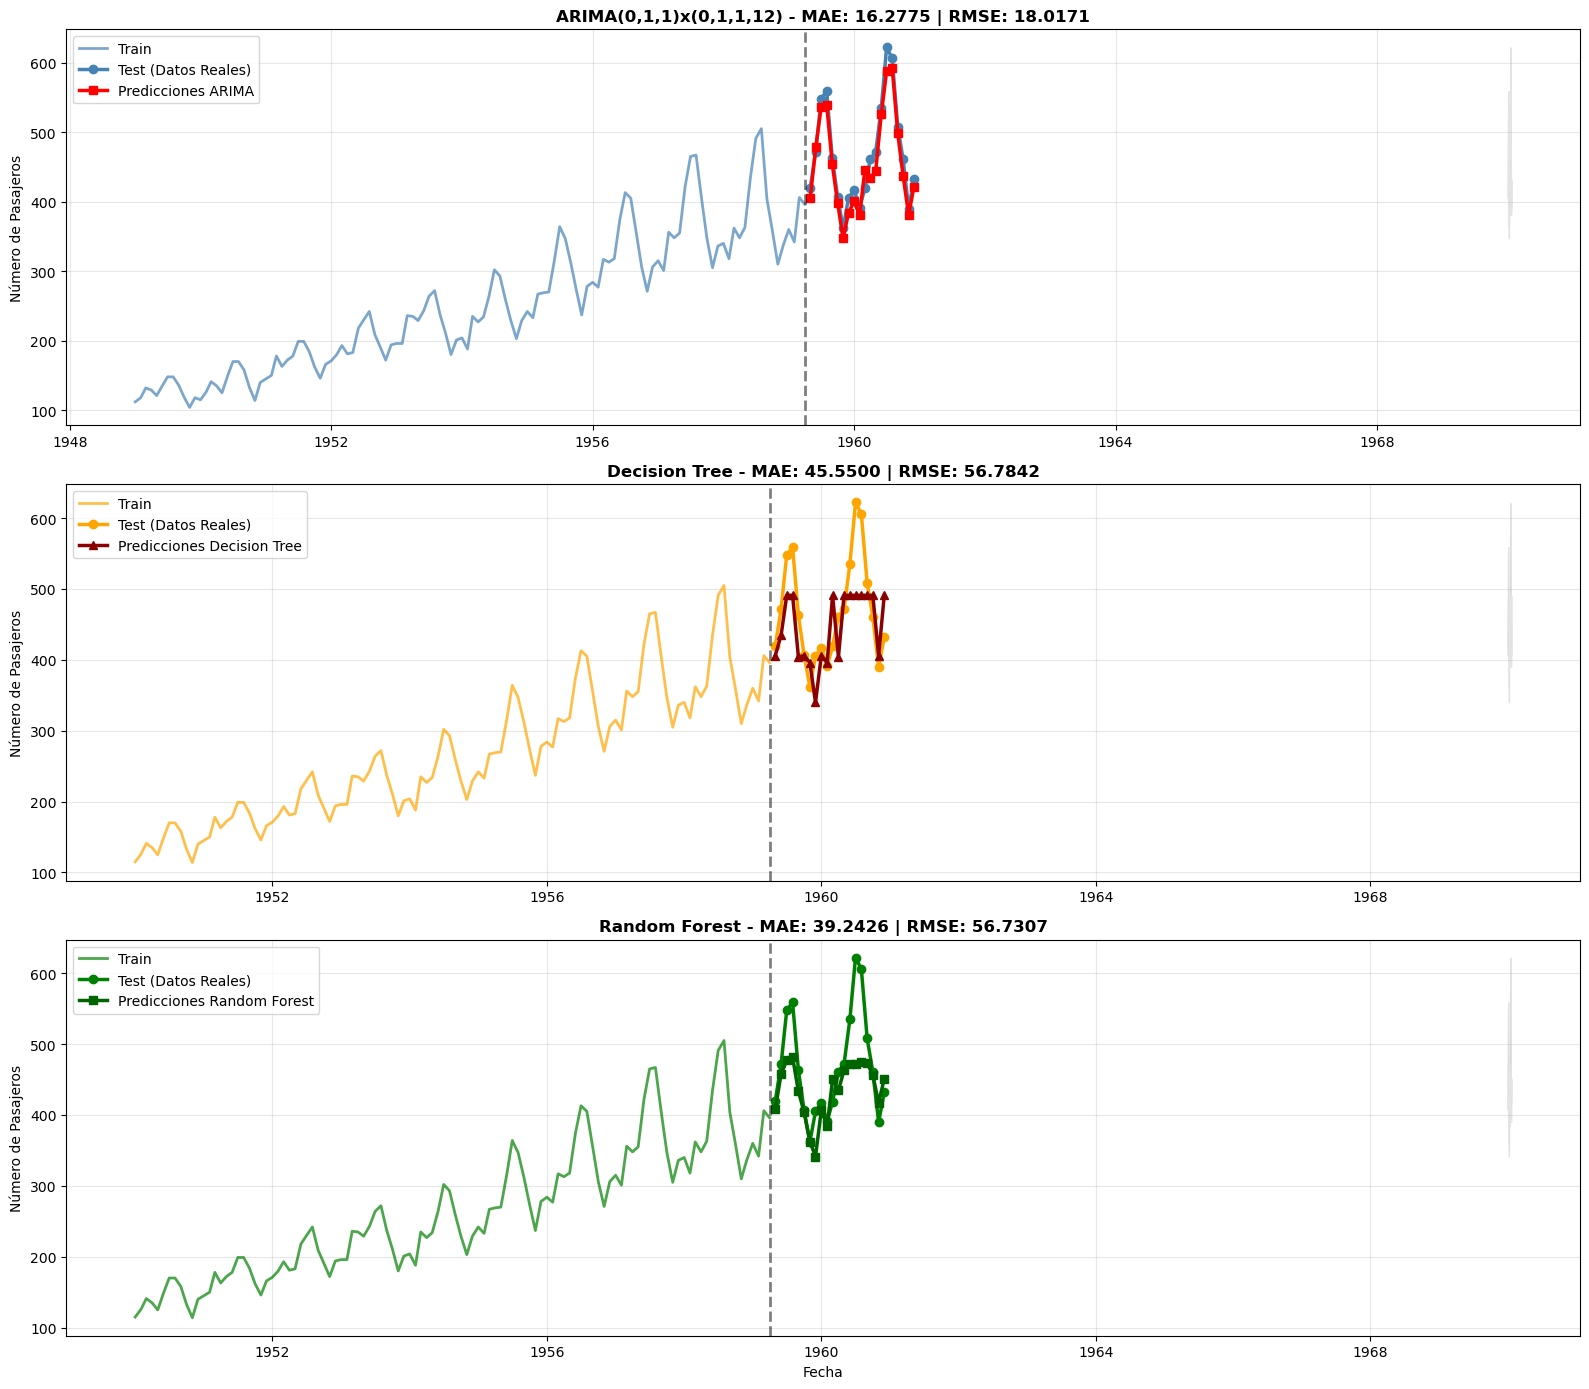


✓ Visualización completada


In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparar datos para modelos supervisados
def create_lagged_features(series, n_lags=12):
    """Crear matriz de features con lags"""
    X = []
    y = []
    for i in range(n_lags, len(series)):
        X.append(series[i-n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Crear features en escala logarítmica
X, y = create_lagged_features(df['log_value'].values, n_lags=12)

# Split train/test (misma proporción que antes)
split_idx = len(X) - 20
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ============================================================================
# MODELO 1: DECISION TREE
# ============================================================================

dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred_log = dt_model.predict(X_test)
dt_pred = np.exp(dt_pred_log)
y_test_original = np.exp(y_test)
y_train_original = np.exp(y_train)

dt_mae = mean_absolute_error(y_test_original, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test_original, dt_pred))

print("=" * 70)
print("DECISION TREE - Métricas")
print("=" * 70)
print(f"MAE:  {dt_mae:.4f}")
print(f"RMSE: {dt_rmse:.4f}")
print("=" * 70)

# ============================================================================
# MODELO 2: RANDOM FOREST
# ============================================================================

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred_log = rf_model.predict(X_test)
rf_pred = np.exp(rf_pred_log)

rf_mae = mean_absolute_error(y_test_original, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_original, rf_pred))

print("\n" + "=" * 70)
print("RANDOM FOREST - Métricas")
print("=" * 70)
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print("=" * 70)

# ============================================================================
# MODELO 3: ARIMA (para comparativa)
# ============================================================================

model_arima = ARIMA(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
model_arima_fit = model_arima.fit()

arima_pred_log = model_arima_fit.get_forecast(steps=len(test)).predicted_mean
arima_pred = np.exp(arima_pred_log)

arima_mae = 16.2775
arima_rmse = 18.0171

# ============================================================================
# COMPARATIVA GENERAL
# ============================================================================

print("\n" + "=" * 70)
print("COMPARATIVA DE TODOS LOS MODELOS")
print("=" * 70)
print(f"{'Modelo':<30} {'MAE':<15} {'RMSE':<15}")
print("-" * 70)
print(f"{'ARIMA(0,1,1)x(0,1,1,12)':<30} {arima_mae:<15.4f} {arima_rmse:<15.4f}")
print(f"{'Decision Tree':<30} {dt_mae:<15.4f} {dt_rmse:<15.4f}")
print(f"{'Random Forest':<30} {rf_mae:<15.4f} {rf_rmse:<15.4f}")
print("=" * 70)

# Identificar el mejor modelo
modelos = {
    'ARIMA(0,1,1)x(0,1,1,12)': arima_mae,
    'Decision Tree': dt_mae,
    'Random Forest': rf_mae
}
mejor_modelo = min(modelos, key=modelos.get)
print(f"\n✓ MEJOR MODELO: {mejor_modelo} (MAE = {modelos[mejor_modelo]:.4f})")

# ============================================================================
# VISUALIZACIONES INDIVIDUALES (UNA POR MODELO)
# ============================================================================

# Fechas para supervisados
train_dates_sup = df['date'].iloc[12:12+len(y_train)].reset_index(drop=True)
test_dates_sup = df['date'].iloc[12+len(y_train):].reset_index(drop=True)

# Fechas para ARIMA
train_dates_arima = df['date'].iloc[:train_size].reset_index(drop=True)
test_dates_arima = df['date'].iloc[train_size:].reset_index(drop=True)
train_original_arima = np.exp(train)
test_original_arima = np.exp(test)

# ============================================================================
# GRÁFICA 1: ARIMA
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ARIMA
axes[0].plot(train_dates_arima, train_original_arima.values, 
            label='Train', linewidth=2, color='steelblue', alpha=0.7)
axes[0].plot(test_dates_arima, test_original_arima.values, 
            label='Test (Datos Reales)', linewidth=2.5, color='steelblue', marker='o')
axes[0].plot(test_dates_arima, arima_pred.values, 
            label='Predicciones ARIMA', linewidth=2.5, color='red', marker='s')
axes[0].axvline(x=train_dates_arima.iloc[-1], color='black', linestyle='--', linewidth=2, alpha=0.5)
axes[0].fill_between(range(len(test_dates_arima)), test_original_arima.values, 
                     arima_pred.values, alpha=0.2, color='gray')
axes[0].set_title(f'ARIMA(0,1,1)x(0,1,1,12) - MAE: {arima_mae:.4f} | RMSE: {arima_rmse:.4f}', 
                 fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Pasajeros')
axes[0].legend(fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# ============================================================================
# GRÁFICA 2: DECISION TREE
# ============================================================================

axes[1].plot(train_dates_sup, y_train_original, 
            label='Train', linewidth=2, color='orange', alpha=0.7)
axes[1].plot(test_dates_sup, y_test_original, 
            label='Test (Datos Reales)', linewidth=2.5, color='orange', marker='o')
axes[1].plot(test_dates_sup, dt_pred, 
            label='Predicciones Decision Tree', linewidth=2.5, color='darkred', marker='^')
axes[1].axvline(x=train_dates_sup.iloc[-1], color='black', linestyle='--', linewidth=2, alpha=0.5)
axes[1].fill_between(range(len(test_dates_sup)), y_test_original, 
                     dt_pred, alpha=0.2, color='gray')
axes[1].set_title(f'Decision Tree - MAE: {dt_mae:.4f} | RMSE: {dt_rmse:.4f}', 
                 fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Pasajeros')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

# ============================================================================
# GRÁFICA 3: RANDOM FOREST
# ============================================================================

axes[2].plot(train_dates_sup, y_train_original, 
            label='Train', linewidth=2, color='green', alpha=0.7)
axes[2].plot(test_dates_sup, y_test_original, 
            label='Test (Datos Reales)', linewidth=2.5, color='green', marker='o')
axes[2].plot(test_dates_sup, rf_pred, 
            label='Predicciones Random Forest', linewidth=2.5, color='darkgreen', marker='s')
axes[2].axvline(x=train_dates_sup.iloc[-1], color='black', linestyle='--', linewidth=2, alpha=0.5)
axes[2].fill_between(range(len(test_dates_sup)), y_test_original, 
                     rf_pred, alpha=0.2, color='gray')
axes[2].set_title(f'Random Forest - MAE: {rf_mae:.4f} | RMSE: {rf_rmse:.4f}', 
                 fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Número de Pasajeros')
axes[2].legend(fontsize=10, loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualización completada")